In [1]:
import sys
!{sys.executable} -m pip install pandas numpy pyarrow geopandas mapclassify esda libpysal splot folium matplotlib seaborn -q


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("All libraries loaded ✓")

All libraries loaded ✓


In [3]:
#Paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PARQUET_PATH = PROCESSED_DIR / "crimes_filtered_for_model.parquet"

#Load data
df = pd.read_parquet(PARQUET_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['Month'].min()} → {df['Month'].max()}")
print(f"\nSample:\n{df.head(3)}")

Shape: (56657681, 7)

Columns: ['Month', 'Falls within', 'Longitude', 'Latitude', 'LSOA code', 'LSOA name', 'Crime type']

Date range: 2012-01 → 2026-03

Sample:
     Month             Falls within  Longitude   Latitude  LSOA code  \
0  2013-05  Derbyshire Constabulary  -1.359885  53.014737  E01019438   
1  2013-05  Derbyshire Constabulary  -1.486916  52.981598  E01019426   
2  2013-05  Derbyshire Constabulary  -1.591089  52.941784  E01019472   

           LSOA name             Crime type  
0  Amber Valley 012C            Shoplifting  
1  Amber Valley 016B               Burglary  
2  Amber Valley 016D  Anti-social behaviour  


In [4]:
#Aggregate to LSOA-month-crime type level
crime_counts = (
    df.groupby(['LSOA code', 'Falls within', 'Month', 'Crime type'])
    .size()
    .reset_index(name='count')
)

print(f"Shape after aggregation: {crime_counts.shape}")
print(f"\nSample:\n{crime_counts.head()}")
print(f"\nUnique crime types:\n{crime_counts['Crime type'].unique()}")

Shape after aggregation: (26889104, 5)

Sample:
   LSOA code              Falls within    Month                   Crime type  \
0  E01000001  British Transport Police  2012-01                  Other theft   
1  E01000001  British Transport Police  2012-02        Anti-social behaviour   
2  E01000001  British Transport Police  2012-02  Public disorder and weapons   
3  E01000001  British Transport Police  2012-03                  Other theft   
4  E01000001  British Transport Police  2012-04                  Other theft   

   count  
0      1  
1      1  
2      1  
3      1  
4      1  

Unique crime types:
['Other theft' 'Anti-social behaviour' 'Public disorder and weapons'
 'Public order' 'Violence and sexual offences' 'Possession of weapons'
 'Theft from the person' 'Criminal damage and arson' 'Drugs'
 'Bicycle theft' 'Burglary' 'Shoplifting' 'Robbery' 'Violent crime'
 'Other crime' 'Vehicle crime']


In [5]:
#CCHI-style harm weights 
# Based on Cambridge Crime Harm Index / ONS Crime Severity Score logic
# Anti-social behaviour excluded from harm weighting (not a criminal offence)

harm_weights = {
    'Violent crime':                  36,
    'Violence and sexual offences':   36,
    'Robbery':                        36,
    'Possession of weapons':          16,
    'Public disorder and weapons':    16,
    'Public order':                    8,
    'Burglary':                       16,
    'Vehicle crime':                   8,
    'Theft from the person':           8,
    'Shoplifting':                     4,
    'Bicycle theft':                   2,
    'Other theft':                     4,
    'Criminal damage and arson':       8,
    'Drugs':                           8,
    'Other crime':                     4,
    'Anti-social behaviour':           0,  
}

crime_counts['harm_weight'] = crime_counts['Crime type'].map(harm_weights)
crime_counts['harm_demand'] = crime_counts['count'] * crime_counts['harm_weight']

print("Harm weights applied ✓")
print(f"\nSample:\n{crime_counts.head()}")
print(f"\nAny unmapped crime types: {crime_counts['harm_weight'].isna().sum()}")

Harm weights applied ✓

Sample:
   LSOA code              Falls within    Month                   Crime type  \
0  E01000001  British Transport Police  2012-01                  Other theft   
1  E01000001  British Transport Police  2012-02        Anti-social behaviour   
2  E01000001  British Transport Police  2012-02  Public disorder and weapons   
3  E01000001  British Transport Police  2012-03                  Other theft   
4  E01000001  British Transport Police  2012-04                  Other theft   

   count  harm_weight  harm_demand  
0      1            4            4  
1      1            0            0  
2      1           16           16  
3      1            4            4  
4      1            4            4  

Any unmapped crime types: 0


In [6]:
#Aggregate harm demand to LSOA level
lsoa_demand = (
    crime_counts.groupby(['LSOA code', 'Falls within'])
    .agg(
        total_count=('count', 'sum'),
        total_harm_demand=('harm_demand', 'sum')
    )
    .reset_index()
)

print(f"Shape: {lsoa_demand.shape}")
print(f"\nSample:\n{lsoa_demand.head()}")
print(f"\nTotal LSOAs: {lsoa_demand['LSOA code'].nunique()}")
print(f"Total forces: {lsoa_demand['Falls within'].nunique()}")

Shape: (96296, 4)

Sample:
   LSOA code                 Falls within  total_count  total_harm_demand
0  E01000001     British Transport Police          138               1670
1  E01000001        City of London Police         2027              17508
2  E01000001  Metropolitan Police Service          339               3358
3  E01000002     British Transport Police          251               3636
4  E01000002  Cambridgeshire Constabulary            1                 36

Total LSOAs: 36747
Total forces: 44


In [7]:
import urllib.request
import zipfile

# ── Download LSOA boundaries (England & Wales) ─────────────────────────────────
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
SPATIAL_DIR.mkdir(parents=True, exist_ok=True)

URL = "https://open-geography-portalx-ons.hub.arcgis.com/api/download/v1/items/45a1edd6de754a48a78e0e93d3e4c5e0/geojson?layers=0"
OUTPUT_FILE = SPATIAL_DIR / "lsoa_boundaries.geojson"

if not OUTPUT_FILE.exists():
    print("Downloading LSOA boundaries... (this may take a few minutes)")
    urllib.request.urlretrieve(URL, OUTPUT_FILE)
    print("Download complete ✓")
else:
    print("File already exists, skipping download ✓")

# ── Load boundaries ─────────────────────────────────────────────────────────────
gdf = gpd.read_file(OUTPUT_FILE)
print(f"\nShape: {gdf.shape}")
print(f"Columns: {gdf.columns.tolist()}")
print(f"\nSample:\n{gdf.head(3)}")

HTTPError: HTTP Error 400: Bad Request

In [8]:
#Load LSOA boundaries 
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
SHP_PATH = SPATIAL_DIR / "england_lsoa_2021.shp"

gdf = gpd.read_file(SHP_PATH)

print(f"Shape: {gdf.shape}")
print(f"Columns: {gdf.columns.tolist()}")
print(f"CRS: {gdf.crs}")
print(f"\nSample:\n{gdf.head(3)}")

Shape: (33755, 5)
Columns: ['label', 'lsoa21cd', 'lsoa21nm', 'name', 'geometry']
CRS: EPSG:27700

Sample:
                                           label   lsoa21cd        lsoa21nm  \
0  E92000001E12000003E08000036E02002465E01011905  E01011905  Wakefield 028C   
1  E92000001E12000008E07000178E02007116E01035743  E01035743     Oxford 019C   
2  E92000001E12000008E07000113E02005116E01024616  E01024616      Swale 002D   

             name                                           geometry  
0  Wakefield 028C  POLYGON ((431757.944 419643.827, 431759.407 41...  
1     Oxford 019C  POLYGON ((453387.909 205065.742, 453391.704 20...  
2      Swale 002D  POLYGON ((591784.909 174332.912, 591786 174332...  


In [10]:
#Merge demand data with boundaries 
gdf_demand = gdf.merge(
    lsoa_demand,
    left_on='lsoa21cd',
    right_on='LSOA code',
    how='left'
)

# Fill LSOAs with no recorded crime as 0
gdf_demand['total_count'] = gdf_demand['total_count'].fillna(0)
gdf_demand['total_harm_demand'] = gdf_demand['total_harm_demand'].fillna(0)

print(f"Shape after merge: {gdf_demand.shape}")
print(f"LSOAs with no crime data: {gdf_demand['total_count'].eq(0).sum()}")
print(f"\nSample:\n{gdf_demand[['lsoa21cd', 'Falls within', 'total_count', 'total_harm_demand']].head()}")

Shape after merge: (87656, 9)
LSOAs with no crime data: 30

Sample:
    lsoa21cd                 Falls within  total_count  total_harm_demand
0  E01011905        West Yorkshire Police       1333.0            18566.0
1  E01035743         Thames Valley Police        319.0             5176.0
2  E01024616                  Kent Police       1726.0            26754.0
3  E01024616  Metropolitan Police Service          2.0               72.0
4  E01004171  Metropolitan Police Service        823.0            11530.0


In [12]:
#Remove British Transport Police (cross-boundary force)
gdf_demand = gdf_demand[gdf_demand['Falls within'] != 'British Transport Police']

# For any remaining duplicates keep the row with highest total_harm_demand
gdf_demand = (
    gdf_demand
    .sort_values('total_harm_demand', ascending=False)
    .drop_duplicates(subset='lsoa21cd', keep='first')
    .reset_index(drop=True)
)

print(f"Shape after deduplication: {gdf_demand.shape}")
print(f"Unique LSOAs: {gdf_demand['lsoa21cd'].nunique()}")
print(f"Unique forces: {gdf_demand['Falls within'].nunique()}")

Shape after deduplication: (33755, 9)
Unique LSOAs: 33755
Unique forces: 39


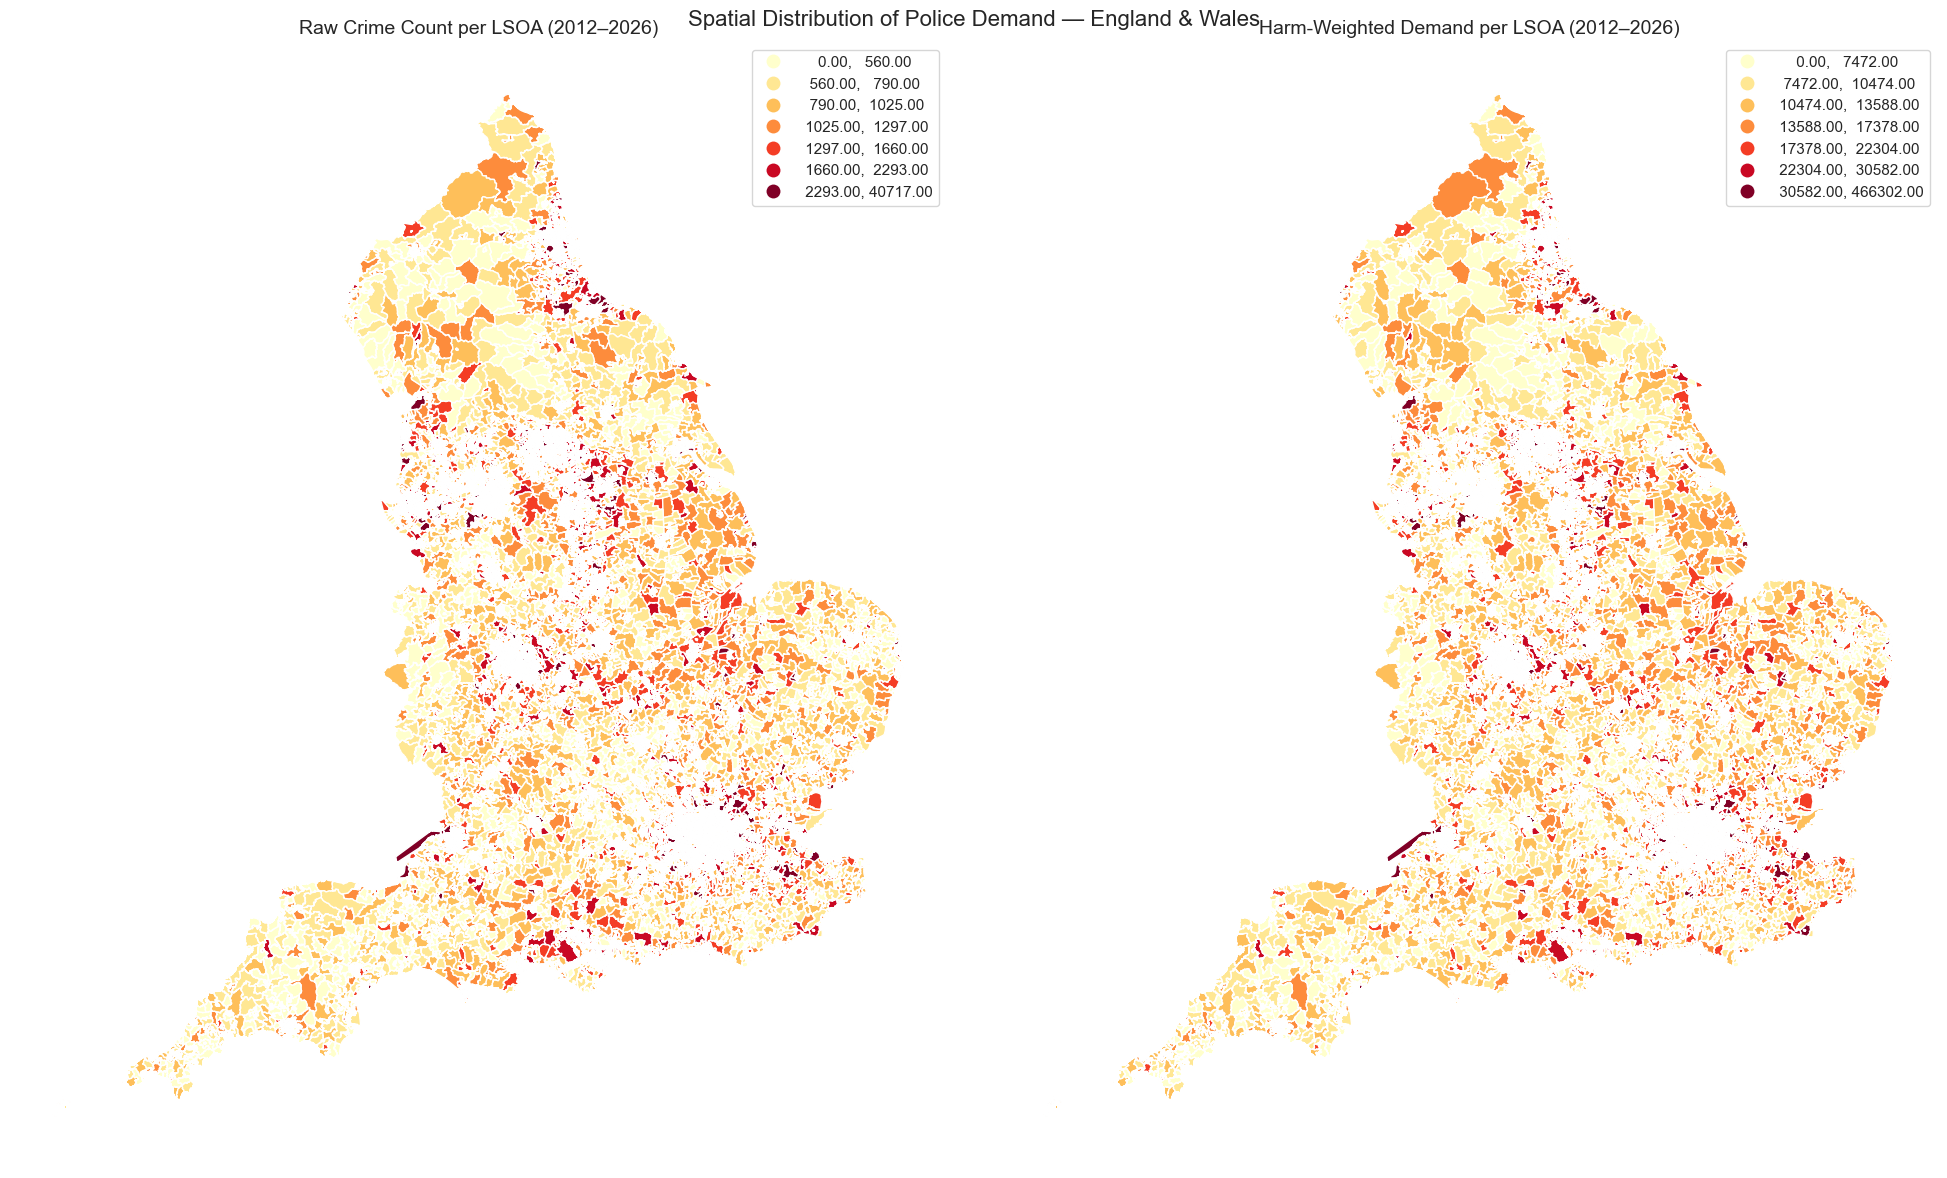

In [14]:
#Plot choropleth: Total Harm Demand per LSOA
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Raw crime count
gdf_demand.plot(
    column='total_count',
    ax=axes[0],
    cmap='YlOrRd',
    scheme='quantiles',
    k=7,
    legend=True
)
axes[0].set_title('Raw Crime Count per LSOA (2012–2026)', fontsize=14)
axes[0].axis('off')

# Harm weighted demand
gdf_demand.plot(
    column='total_harm_demand',
    ax=axes[1],
    cmap='YlOrRd',
    scheme='quantiles',
    k=7,
    legend=True
)
axes[1].set_title('Harm-Weighted Demand per LSOA (2012–2026)', fontsize=14)
axes[1].axis('off')

plt.suptitle('Spatial Distribution of Police Demand — England & Wales', fontsize=16)
plt.tight_layout()
plt.show()